# Payload (ETC) Functional Test Analysis

Analyzes focus, sharpness, and astigmatism in payload camera test captures across functional test runs (pre/post vibe, TVAC thermal cycling). See `src/payload_analysis/` for the underlying functions — this notebook is just the run log.

In [1]:
import sys
sys.path.insert(0, '../src')

from payload_analysis import (
    analyze_payload_image,
    analyze_payload_directory,
    compute_focus_scores,
    analyze_astigmatism_by_angle,
    plot_payload_metrics,
    plot_payload_metrics_timeline,
    plot_focus_scores,
    add_temperatures_and_plot,
    DATA_DIR,
)


## Single-image sanity check

Quick look at one capture before running a full batch, to confirm the metrics look reasonable.

In [2]:
sample_image = DATA_DIR / 'sample_capture.jpg'  # swap in a real capture path
if sample_image.exists():
    print(analyze_payload_image(str(sample_image)))
else:
    print(f"No sample image at {sample_image} — skipping sanity check")


No sample image at /Users/sharonchan/Downloads/aleasat-payload-analysis/data/sample_capture.jpg — skipping sanity check


## Pre/post-vibe functional test runs

Each call processes all `angle-*` subdirectories in a test-run folder and writes a metrics CSV to `results/`.

In [3]:
vibe_test_dirs = [
    DATA_DIR / '260609_pre_vibe_func_test',
    DATA_DIR / '260612_post_vibe_func_test',
    DATA_DIR / '260615_pre_vibe2_func_test',
    DATA_DIR / '260616_post_vibe2_func_test',
]

for test_dir in vibe_test_dirs:
    analyze_payload_directory(test_dir)


Processing angle-0...
Processing angle-180...
Processing angle-90...

All results saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/260609_pre_vibe_func_test_all_metrics.csv
Processing angle-0...
Processing angle-180...
Processing angle-270...
Processing angle-90...

All results saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/260612_post_vibe_func_test_all_metrics.csv
Processing angle-0...
Processing angle-180...
Processing angle-270...
Processing angle-90...

All results saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/260615_pre_vibe2_func_test_all_metrics.csv
Processing angle-0...
Processing angle-180...
Processing angle-270...
Processing angle-90...

All results saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/260616_post_vibe2_func_test_all_metrics.csv


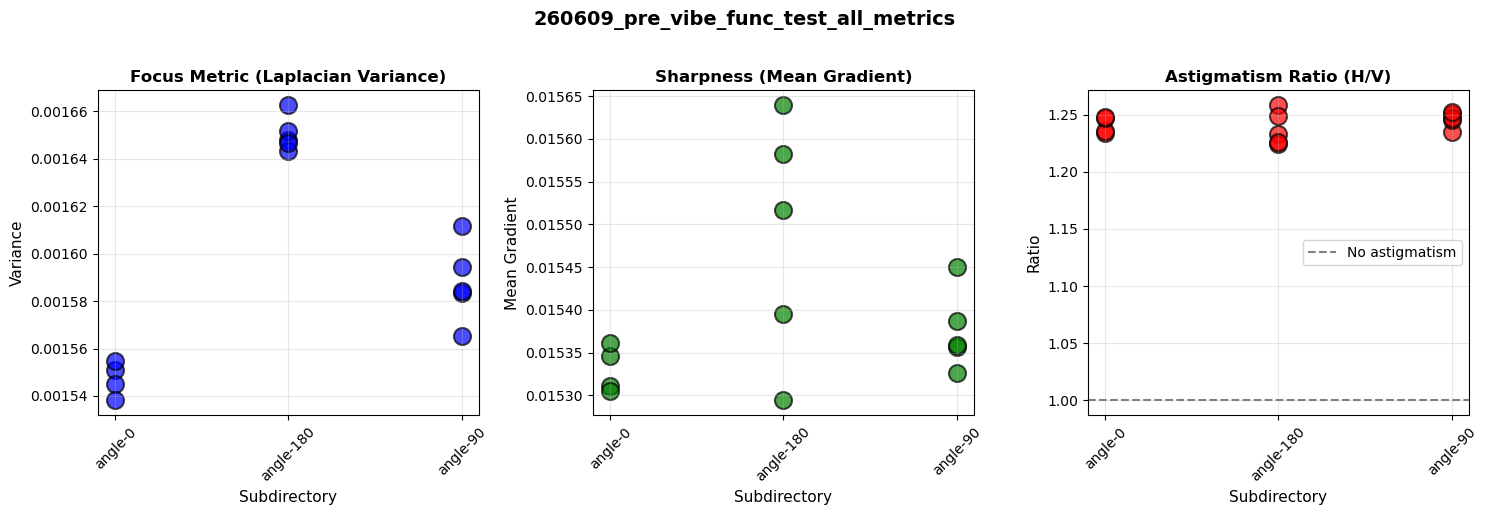

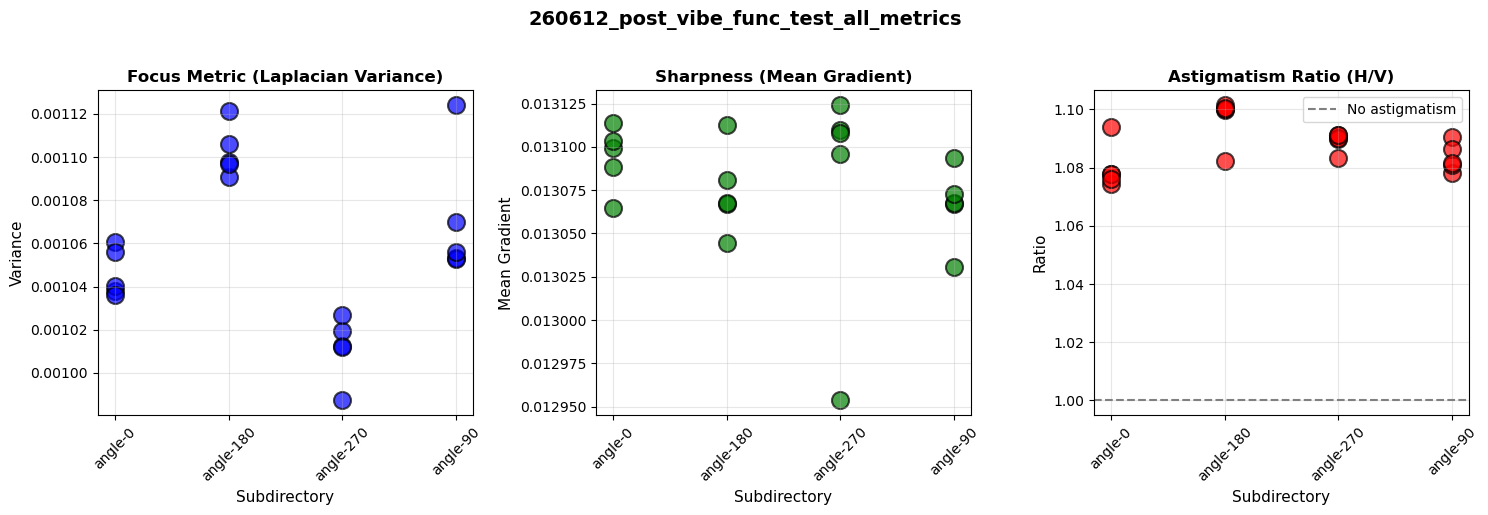

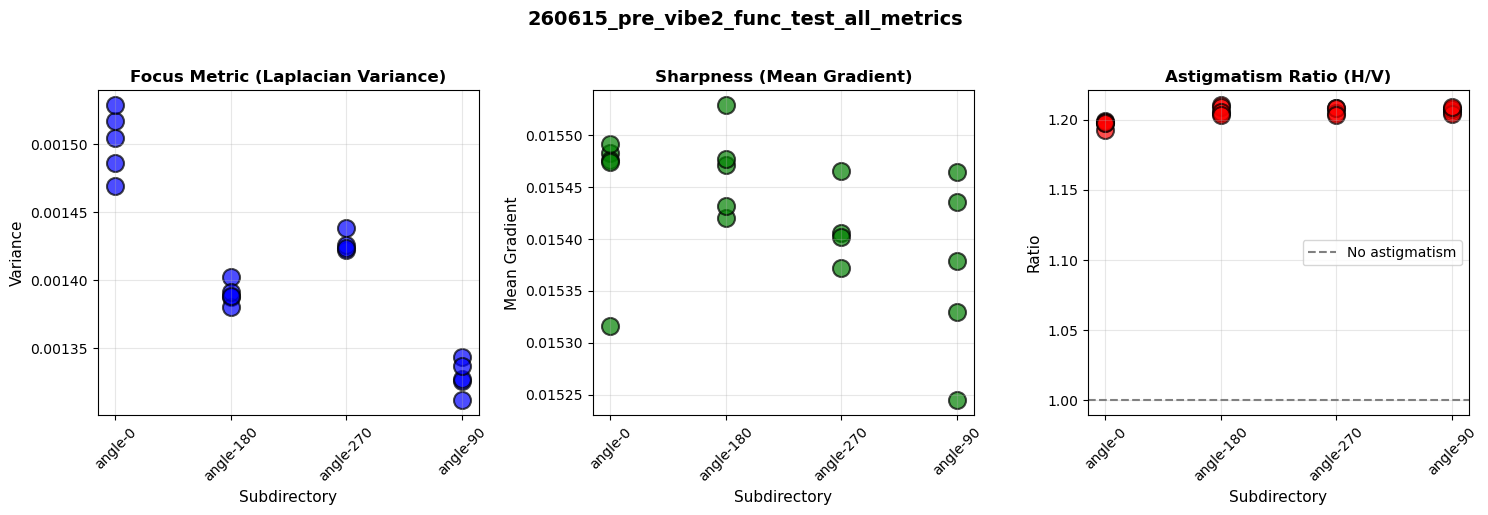

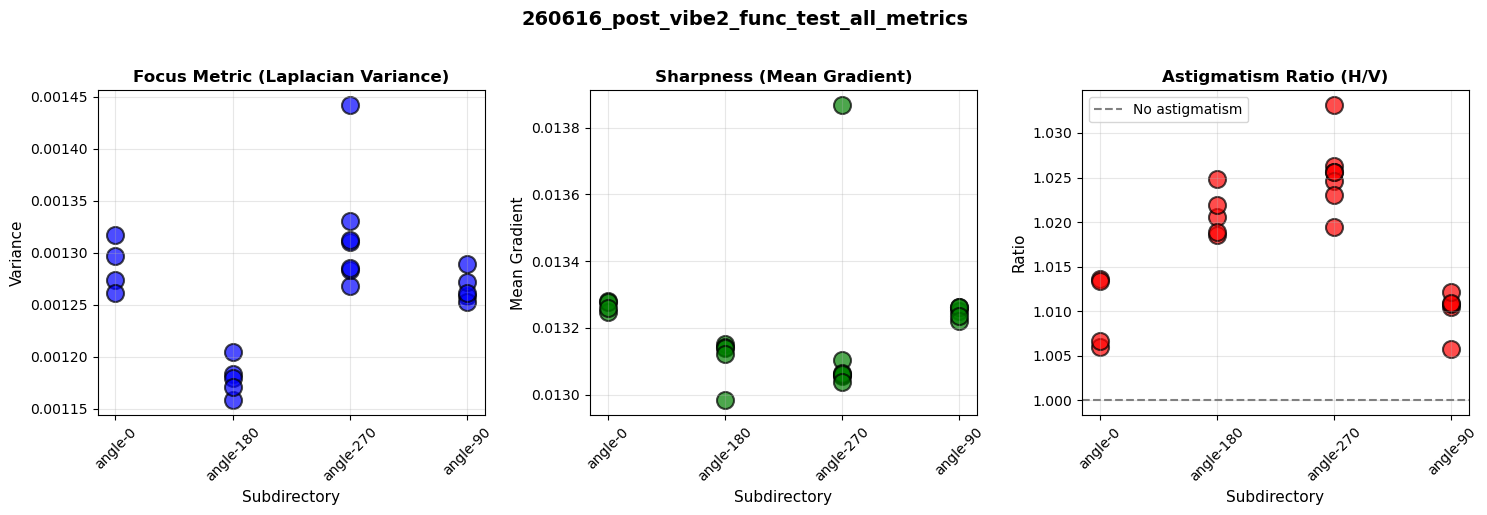

In [4]:
from payload_analysis.config import RESULTS_DIR

vibe_csvs = [RESULTS_DIR / f'{d.name}_all_metrics.csv' for d in vibe_test_dirs]
for csv_path in vibe_csvs:
    plot_payload_metrics(csv_path)


### Timeline across vibe test runs

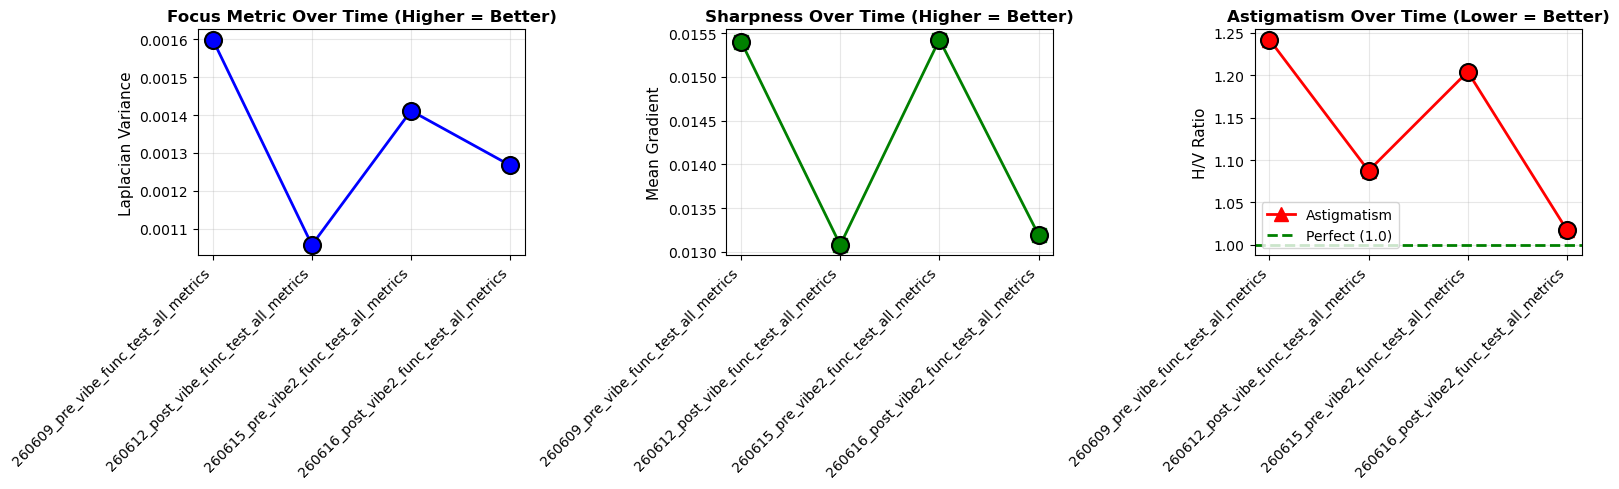

,test_name,focus_metric,sharpness,astigmatism_ratio
0,260609_pre_vibe_func_test_all_metrics,0.001599,0.015402,1.241843
1,260612_post_vibe_func_test_all_metrics,0.001058,0.013078,1.087366
2,260615_pre_vibe2_func_test_all_metrics,0.001411,0.015425,1.204014
3,260616_post_vibe2_func_test_all_metrics,0.001267,0.013194,1.017737


In [5]:
timeline_df = plot_payload_metrics_timeline(vibe_csvs)
timeline_df


### Astigmatism: target tilt vs. optical

If astigmatism ratio varies a lot by angle, it's likely target tilt rather than a real optical astigmatism. See `analyze_astigmatism_by_angle` for the variance threshold used.

In [6]:
# change index for different test directories to analyze astigmatism by angle
analyze_astigmatism_by_angle(vibe_csvs[2])  # 260615_pre_vibe2_func_test


Astigmatism by angle:
    angle  astigmatism_ratio
0       0           1.197821
1       0           1.192585
2       0           1.198827
3       0           1.198476
4       0           1.197810
5     180           1.204706
6     180           1.210449
7     180           1.208908
8     180           1.205320
9     180           1.203696
10    270           1.208325
11    270           1.205071
12    270           1.208073
13    270           1.203158
14     90           1.207412
15     90           1.205455
16     90           1.207516
17     90           1.203763
18     90           1.208892

Mean: 1.204
Std dev: 0.005
-> Low variance: likely optical astigmatism


,focus_metric,sharpness,astigmatism_ratio,edge_count,subdir,angle
0,0.001486,0.015483,1.197821,3364,angle-0,0
1,0.001469,0.015316,1.192585,3428,angle-0,0
2,0.001504,0.015476,1.198827,3374,angle-0,0
3,0.001517,0.015492,1.198476,3356,angle-0,0
4,0.001529,0.015475,1.197810,3345,angle-0,0
5,0.001402,0.015529,1.204706,3281,angle-180,180
6,0.001388,0.015472,1.210449,3294,angle-180,180
7,0.001380,0.015477,1.208908,3244,angle-180,180
8,0.001391,0.015421,1.205320,3276,angle-180,180
9,0.001388,0.015432,1.203696,3293,angle-180,180


## TRP (thermal cycling) run

Same metric set, run over the full TRP master directory (one CSV per run instead of per angle-subset).

In [7]:
trp_dir = DATA_DIR / 'New TRP'
trp_df = analyze_payload_directory(trp_dir)


  No images in 260609_pre_vibe_func_test
  No images in 260612_post_vibe_func_test
  No images in 260615_pre_vibe2_func_test
  No images in 260616_post_vibe2_func_test
Processing CYCLE1_MAX_OP_20260623-1055...
Processing CYCLE1_MIN_OP_20260623-1347...
Processing CYCLE2_MAX_OP_20260623-1550...
Processing CYCLE2_MIN_OP_20260623-1948...
Processing CYCLE3_MAX_OP_20260623-2226...
Processing CYCLE3_MIN_OP_20260624-1024...
Processing STRESS_MIN_OP_20260626-1018...
Processing THERMAL_MIN_OP_20260625-1317...
Processing TVACOFF_20260626-1236...
Processing blur...

All results saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/New TRP_all_metrics.csv


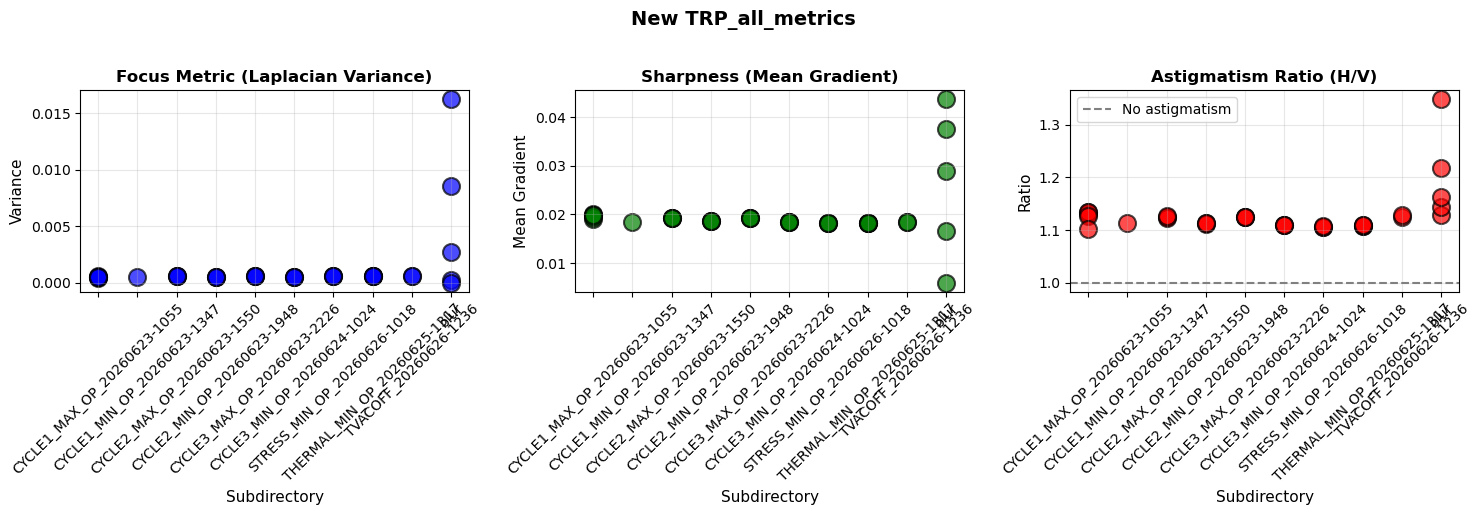

In [8]:
trp_summary = plot_payload_metrics(RESULTS_DIR / 'New TRP_all_metrics.csv')


## LoG focus score vs. temperature

Independent focus metric (LoG-based) as a cross-check on the Laplacian-variance metric above, plotted against operating temperature per `config.TEMP_MAP`.

No images in 260609_pre_vibe_func_test
No images in 260612_post_vibe_func_test
No images in 260615_pre_vibe2_func_test
No images in 260616_post_vibe2_func_test
Processing CYCLE1_MAX_OP_20260623-1055...
Processing CYCLE1_MIN_OP_20260623-1347...
Processing CYCLE2_MAX_OP_20260623-1550...
Processing CYCLE2_MIN_OP_20260623-1948...
Processing CYCLE3_MAX_OP_20260623-2226...
Processing CYCLE3_MIN_OP_20260624-1024...
Processing STRESS_MIN_OP_20260626-1018...
Processing THERMAL_MIN_OP_20260625-1317...
Processing TVACOFF_20260626-1236...
Processing blur...

Focus scores saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/New TRP_focus_scores.csv


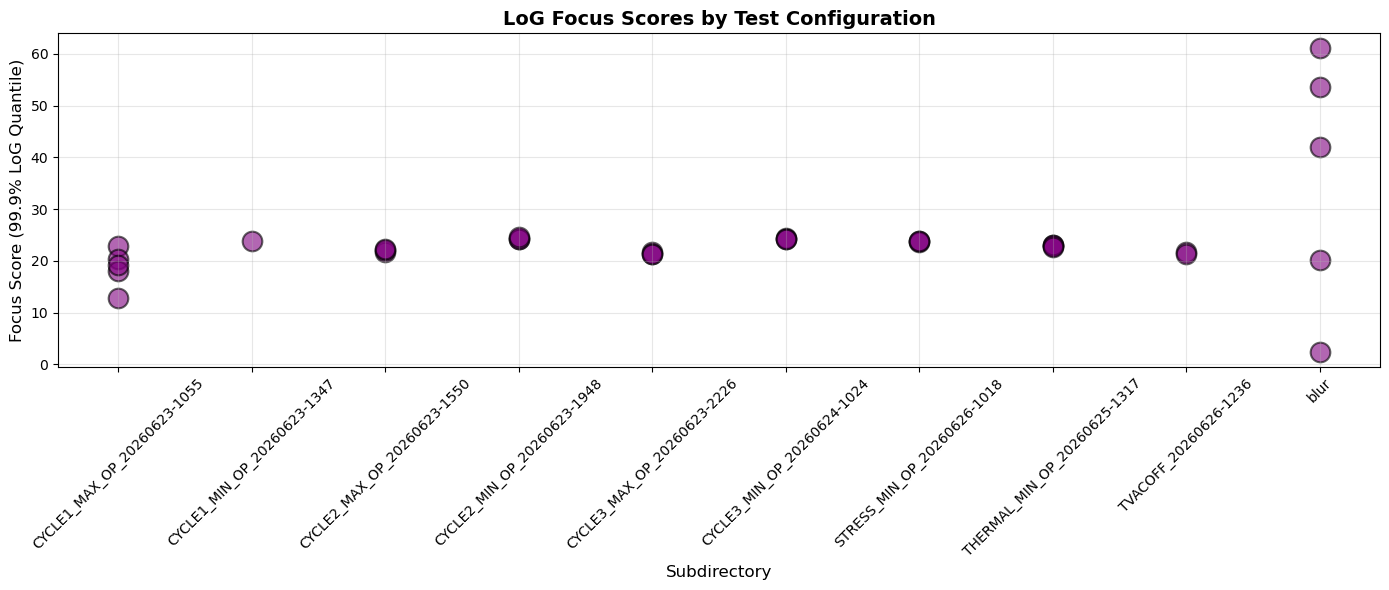

,filename,subdir,focus_score
27,1600.BLUR.1.png,blur,61.035679
28,1600.BLUR.2.png,blur,53.596111
29,1600.BLUR.3.png,blur,41.996346
30,1600.BLUR.4.png,blur,20.186596
31,1600.BLUR.5.png,blur,2.473461


In [11]:
focus_df = compute_focus_scores(trp_dir)
plot_focus_scores(focus_df)

blur_batch = focus_df[focus_df["filename"].str.startswith("1600")]

blur_batch


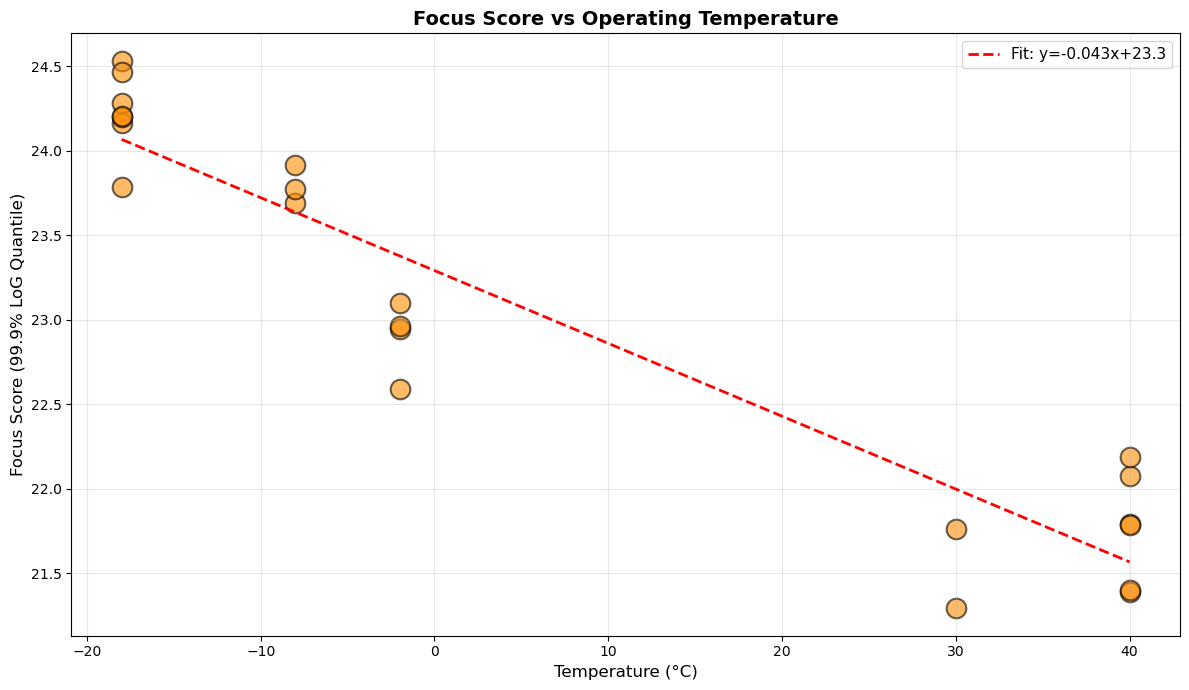

,subdir,temperature,focus_score
5,CYCLE1_MIN_OP_20260623-1347,-18.0,23.785406
17,CYCLE3_MIN_OP_20260624-1024,-18.0,24.203861
16,CYCLE3_MIN_OP_20260624-1024,-18.0,24.197813
11,CYCLE2_MIN_OP_20260623-1948,-18.0,24.533407
10,CYCLE2_MIN_OP_20260623-1948,-18.0,24.165613
15,CYCLE3_MIN_OP_20260624-1024,-18.0,24.468134
9,CYCLE2_MIN_OP_20260623-1948,-18.0,24.281239
18,STRESS_MIN_OP_20260626-1018,-8.0,23.915079
19,STRESS_MIN_OP_20260626-1018,-8.0,23.691334
20,STRESS_MIN_OP_20260626-1018,-8.0,23.773436


In [10]:
focus_df_with_temp = add_temperatures_and_plot(focus_df)
focus_df_with_temp[['subdir', 'temperature', 'focus_score']].sort_values('temperature')
